<a href="https://colab.research.google.com/github/HoFangHuy/AI/blob/main/BTVN_nhandientien.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install matplotlib
!pip install scikit-learn

In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

In [6]:
from google.colab import files
uploaded = files.upload()  # Chọn file .zip chứa folder "ảnh train model"

Saving ảnh train model.zip to ảnh train model (2).zip


In [7]:
import zipfile
import os

with zipfile.ZipFile("ảnh train model.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Kiểm tra xem thư mục có đúng không
import os
for root, dirs, files in os.walk("/content/ảnh train model"):
    print(root)
    break


/content/ảnh train model


In [22]:
import numpy as np
import os
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

data = []
labels = []

classes = [
    "1.000 đồng",
    "10.000 đồng",
    "100.000 đồng",
    "2.000 đồng",
    "20.000 đồng",
    "200.000 đồng",
    "5.000 đồng",
    "50.000 đồng",
    "500.000 đồng"
]

img_size = (100, 100)  # Kích thước ảnh cho ANN

for i, label in enumerate(classes):
    folder_path = f"/content/ảnh train model/{label}"
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = load_img(img_path, target_size=img_size)
        img_array = img_to_array(img) / 255.0
        data.append(img_array)
        labels.append(i)

data = np.array(data)
labels = to_categorical(labels)

x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=img_size + (3,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 30000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       3,840,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 9)                   │             585 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,848,969 (14.68 MB)

 Trainable params: 3,848,969 (14.68 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.fit(x_train, y_train, epochs=50, batch_size=16, validation_data=(x_test, y_test))

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.0645 - loss: 13.7682 - val_accuracy: 0.0556 - val_loss: 16.3066
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.1045 - loss: 11.7166 - val_accuracy: 0.1111 - val_loss: 10.7957
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1273 - loss: 7.6067 - val_accuracy: 0.1111 - val_loss: 5.2146
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.0145 - loss: 5.9813 - val_accuracy: 0.1111 - val_loss: 4.9474
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2190 - loss: 6.4048 - val_accuracy: 0.1111 - val_loss: 4.3693
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3194 - loss: 2.9936 - val_accuracy: 0.1111 - val_loss: 3.6189
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2425 - loss: 2.4464 - val_accuracy: 0.2778 - val_loss: 2.1754
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4942 - loss: 2.1260 - val_accuracy: 0.2778 - val_loss: 2.

In [35]:
model.save("vietnamese_money_ann_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


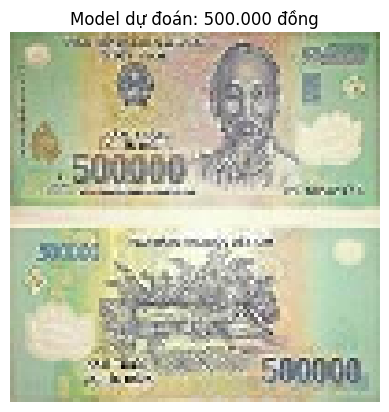

In [33]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

test_img_path = "/content/500 lan 2.jpg"  # đường dẫn đến ảnh test
img = load_img(test_img_path, target_size=img_size)
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_label = classes[np.argmax(prediction)]

plt.imshow(img)
plt.axis('off')
plt.title(f"Model dự đoán: {predicted_label}")
plt.show()
